# Trabalho Final - notebook base do projeto da Danielle

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **Homens e mulheres são impactados (desempenho, confiança, ansiedade) da mesma forma pelo uso de IA em STEM?**

(gênero, condição experimental de uso de IA, desempenho acadêmico, confiança na sala de aula e ansiedade em STEM)

--- O uso de Inteligência Artificial (IA) como apoio pedagógico em disciplinas de STEM (Ciência, Tecnologia, Engenharia e Matemática) vem crescendo, mas não é óbvio que seu efeito seja igual para todos os grupos de estudantes. Neste trabalho será utilizado o conjunto de dados *STEM Education Research Data*, que reúne 847 estudantes distribuídos em 4 condições experimentais (Controle, apenas treino de *mindset* de crescimento, apenas IA, e IA + *mindset*), com medidas repetidas de ansiedade, conforto em sala de aula, motivação e crenças de crescimento em três momentos (linha de base, meio e final do estudo), além de notas de desempenho acadêmico. Pretende-se avaliar se homens e mulheres respondem de forma parecida ou diferente ao uso de IA nessas três dimensões citadas na pergunta de pesquisa — desempenho, confiança e ansiedade — comparando as médias de cada grupo de gênero dentro de cada condição experimental, sem supor de antemão que o efeito da IA seja igual (ou diferente) entre os gêneros.

In [2]:
# Carrega o dataset (zip com um unico CSV) e mostra as primeiras linhas
# para conferir o formato das colunas

df = pd.read_csv("../datasets/danielle/stem_education_research_data.zip", compression='zip')

df.head()

,participant_id,university,course_type,condition,age,age_group,gender,ethnicity,act_score,baseline_intrinsic_motivation,...,perceived_ai_usefulness,perceived_ai_ease_of_use,perceived_instructor_universal_beliefs,perceived_peer_support,perceived_faculty_support,course_grade,final_exam_score,assignment_average,class_attendance_rate,study_hours_per_week
0,S0001,University A,Computer Science,AI Only,41,Non-traditional (>22),Female,White,23.0,4.58,...,4.71,4.26,3.85,4.05,4.23,78.7,78.6,82.1,0.894,10.0
1,S0002,University A,Mathematics,Mindset Only,22,Traditional (18-22),Female,White,21.9,4.61,...,NaN,NaN,5.13,5.26,4.78,82.0,76.5,86.3,0.873,9.7
2,S0003,University A,Computer Science,Control,18,Traditional (18-22),Male,Hispanic/Latino,20.7,4.13,...,NaN,NaN,4.18,4.52,4.09,71.6,71.4,77.6,0.869,6.4
3,S0004,University A,Physics,Control,29,Non-traditional (>22),Male,White,25.4,4.91,...,NaN,NaN,3.82,4.19,4.00,82.8,82.1,88.7,0.857,7.2
4,S0005,University A,Biology,Control,20,Traditional (18-22),Female,White,21.9,4.75,...,NaN,NaN,4.57,4.20,4.42,67.9,67.3,71.1,0.826,5.0


In [3]:
# Lista todas as colunas disponiveis no dataset (31 no total)

df.columns

Index(['participant_id', 'university', 'course_type', 'condition', 'age',
       'age_group', 'gender', 'ethnicity', 'act_score',
       'baseline_intrinsic_motivation', 'baseline_stem_anxiety',
       'baseline_classroom_comfort', 'baseline_growth_beliefs',
       'mid_intrinsic_motivation', 'mid_stem_anxiety', 'mid_classroom_comfort',
       'mid_growth_beliefs', 'final_intrinsic_motivation',
       'final_stem_anxiety', 'final_classroom_comfort', 'final_growth_beliefs',
       'perceived_ai_usefulness', 'perceived_ai_ease_of_use',
       'perceived_instructor_universal_beliefs', 'perceived_peer_support',
       'perceived_faculty_support', 'course_grade', 'final_exam_score',
       'assignment_average', 'class_attendance_rate', 'study_hours_per_week'],
      dtype='str')

**Escolha do subconjunto de colunas:** o dataset tem 31 colunas, muitas delas repetidas em três momentos do estudo — `baseline_*`, `mid_*` e `final_*` (ex.: `baseline_stem_anxiety`, `mid_stem_anxiety`, `final_stem_anxiety`). Para responder à pergunta de pesquisa, que trata do **impacto ao final** do uso de IA, este notebook usa apenas as versões `final_*` dessas variáveis (o resultado depois de toda a intervenção), e não as versões `baseline_*`/`mid_*`, que descrevem o meio do caminho e não o efeito final.

O subconjunto escolhido é:
- `gender` — para comparar homens e mulheres (variável central da pergunta);
- `condition` — indica se a pessoa recebeu ou não intervenção de IA (`AI Only`, `AI + Mindset`, `Mindset Only`, `Control`);
- `course_grade` e `final_exam_score` — **desempenho**, medido diretamente por notas;
- `final_stem_anxiety` — **ansiedade** em STEM ao final do estudo;
- `final_classroom_comfort` — usada como aproximação de **confiança** (justificativa na célula de classificação desta variável, mais abaixo).

Ficam **de fora** desta análise, por não serem necessárias para responder à pergunta: `participant_id` (identificador); `university`, `course_type`, `ethnicity`, `age`, `age_group`, `act_score` (características demográficas/institucionais, não citadas na pergunta); todas as colunas `baseline_*` e `mid_*` (não são o efeito "final" que a pergunta pede); `final_intrinsic_motivation` e `final_growth_beliefs` (dimensões psicológicas relacionadas, mas não citadas explicitamente na pergunta — motivação e crença de crescimento não são o mesmo que confiança ou ansiedade); `perceived_ai_usefulness`, `perceived_ai_ease_of_use`, `perceived_instructor_universal_beliefs`, `perceived_peer_support`, `perceived_faculty_support` (percepções sobre IA/apoio social, fora do escopo da pergunta); `assignment_average`, `class_attendance_rate`, `study_hours_per_week` (indicadores de desempenho/engajamento adicionais, redundantes com `course_grade`/`final_exam_score` para o que a pergunta pede).

## Classificação das variáveis associadas à pergunta de pesquisa

In [4]:
# Genero: variavel categorica central da pergunta de pesquisa
df["gender"].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

O gênero é uma variável **categórica** e possui 3 categorias no dataset: `Female`, `Male` e `Other`. Como a pergunta de pesquisa fala especificamente em "homens e mulheres", e o grupo `Other` tem apenas 12 das 847 pessoas (1.4% da amostra, pequeno demais para gerar uma média estável), a etapa de limpeza abaixo restringe a análise a `Female` e `Male`.

In [5]:
# Condicao experimental: indica se a pessoa recebeu intervencao de IA
df["condition"].unique()

<StringArray>
['AI Only', 'Mindset Only', 'Control', 'AI + Mindset']
Length: 4, dtype: str

A condição experimental é uma variável **categórica** e possui 4 categorias: `Control` (grupo controle, sem intervenção), `Mindset Only` (apenas treino de *mindset* de crescimento, sem IA), `AI Only` (apenas uso de IA) e `AI + Mindset` (IA combinada com o treino de *mindset*). Para a pergunta de pesquisa, o que importa é **quem usou IA**: as condições `AI Only` e `AI + Mindset` correspondem a "usou IA", enquanto `Control` e `Mindset Only` correspondem a "não usou IA". Essa variável derivada (`recebeu_ia`) é criada mais adiante, na seção de estatística descritiva.

In [6]:
# Desempenho (1/2): nota final do curso
df["course_grade"].unique()

array([78.7, 82. , 71.6, 82.8, 67.9, 80.7, 80.3, 82.3, 83.8, 76.1, 88.7,
       80.9, 83.1, 67.7, 81. , 75.8, 95.4, 89.5, 86.9, 72.3, 83.2, 70.2,
       72.8, 77.1, 89.8, 80. , 81.7, 88. , 85.9, 79. , 75.6, 74. , 93.8,
       70.3, 79.3, 89.7, 83.6, 86.7, 82.1, 81.3, 85. , 85.3, 75.2, 78.5,
       74.9, 84.5, 74.6, 92.3, 76. , 67.8, 85.2, 75.7, 78.1, 86.2, 81.5,
       83. , 84.9, 70.1, 78.4, 84.3, 81.2, 76.5, 87.3, 79.4, 90.1, 84. ,
       77.4, 80.6, 82.4, 75.9, 79.1, 88.2, 74.1, 66.3, 72. , 76.8, 74.8,
       76.7, 74.7, 86. , 79.2, 80.2, 79.6, 92.2, 80.5, 87.2, 78.2, 71.5,
       84.1, 80.1, 78.8, 73.4, 82.9, 75.4, 82.5, 70. , 78. , 89.6, 68.3,
       86.3, 89.1, 72.9, 88.5, 73.5, 70.9, 78.6, 81.4, 70.8, 85.1, 70.7,
       86.6, 77.8, 71.8, 82.6, 77.3, 76.9, 83.5, 67.3, 68.9, 76.2, 88.6,
       68.4, 77.7, 84.4, 73.6, 75.5, 81.6, 77.2, 85.5, 78.9, 76.3, 91.2,
       83.9, 83.7, 71.4, 87. , 76.6, 73.2, 72.1, 72.7, 84.7, 90.2, 65.5,
       78.3, 69.8, 71.9, 99. , 73. , 88.3, 81.1, 84

A nota final do curso (`course_grade`) é uma variável **numérica** e varia de 60.30 a 99.00 no dataset.

In [7]:
# Desempenho (2/2): nota do exame final
df["final_exam_score"].unique()

array([ 78.6,  76.5,  71.4,  82.1,  67.3,  82.2,  76.2,  86.4,  82.4,
        77.3,  89.4,  84.3,  78.8,  72.3,  83.2,  77.2,  92.7,  90.1,
        88.4,  90.4,  71.1,  88.3,  73.5,  73.1,  76.9,  74.9,  80. ,
        85.2,  83.9,  71.7,  95.7,  68.4,  79.7,  91.4,  87.7,  81.4,
        87.9,  81.1,  78.2,  77.1,  80.4,  74.2,  81.3,  75.8,  87.1,
        73.3,  89.3,  82.3,  83.8,  73.6,  71. ,  86.7,  80.2,  81.8,
        79.2,  89.2,  87. ,  79.5,  84. ,  70.4,  80.6,  81.5,  80.8,
        92.2,  81.9,  78.1,  80.9,  87.4,  90.2,  77.8,  74.6,  68.2,
        68.9,  81.2,  75. ,  79.9,  80.7,  77.9,  83.7,  81. ,  80.5,
        76.6,  92. ,  81.6,  87.8,  74. ,  84.5,  75.6,  74.1,  80.3,
        86.3,  63. ,  85.7,  74.4,  90.5,  88.5,  72. ,  86.9,  77. ,
        71.2,  72.7,  76.8,  77.4,  89. ,  70.9,  68.8,  77.6,  84.2,
        82. ,  84.4,  75.2,  74.8,  73. ,  83.4,  77.5,  61.6,  69.1,
        89.8,  90. ,  70.1,  78.9,  85.9,  65.8,  75.1,  78.5,  78.3,
        91.2,  77.7,

A nota do exame final (`final_exam_score`) é uma variável **numérica** e varia de 56.30 a 100.00 no dataset.

In [8]:
# Ansiedade em STEM ao final do estudo
df["final_stem_anxiety"].unique()

array([2.43, 3.17, 3.91, 3.09, 3.36, 2.29, 2.85, 2.36, 2.65, 3.57, 1.75,
       1.98, 3.41, 3.46, 2.23, 3.1 , 2.37, 1.95, 1.8 , 3.27, 2.68, 3.53,
       3.47, 3.42, 1.96, 2.92, 2.34, 2.52, 3.14, 2.78, 3.5 , 3.03, 3.07,
       1.45, 4.  , 2.63, 2.28, 2.94, 2.18, 3.65, 2.46, 2.11, 2.17, 3.01,
       3.19, 4.07, 3.18, 2.05, 1.89, 1.44, 3.33, 3.51, 1.99, 2.62, 3.68,
       2.72, 2.15, 4.16, 2.67, 3.2 , 2.95, 3.35, 3.78, 3.06, 3.29, 3.58,
       2.83, 3.92, 2.4 , 2.32, 2.8 , 1.78, 1.85, 3.45, 3.44, 3.24, 2.64,
       2.96, 3.11, 2.79, 1.27, 3.04, 3.23, 2.08, 1.92, 3.37, 4.25, 2.82,
       2.77, 2.09, 3.49, 4.13, 3.84, 2.53, 3.25, 1.83, 2.03, 3.16, 2.5 ,
       2.19, 4.26, 2.51, 3.59, 2.56, 2.58, 3.32, 2.71, 3.05, 2.69, 1.67,
       3.99, 3.31, 2.24, 3.43, 2.33, 3.96, 1.93, 4.27, 2.91, 3.12, 2.76,
       3.28, 2.49, 2.21, 2.16, 1.43, 3.3 , 2.6 , 4.56, 2.93, 2.81, 1.77,
       1.61, 2.  , 2.35, 3.22, 3.02, 3.13, 3.61, 3.94, 3.7 , 2.99, 4.12,
       1.74, 2.02, 3.71, 1.35, 1.87, 3.88, 2.04, 3.

A ansiedade em STEM ao final do estudo (`final_stem_anxiety`) é uma variável **numérica** (nota autorreferida) e varia de 1.00 a 4.56 no dataset. O CSV não documenta a escala original do questionário, mas os valores observados (entre 1 e cerca de 4.6) sugerem uma escala Likert provavelmente de 1 a 5 ou de 1 a 6 — isso é uma **hipótese**, não um dado confirmado no arquivo; o que sabemos com certeza é apenas o intervalo de 1.00 a 4.56 realmente registrado.

In [9]:
# Confianca: o dataset nao tem uma coluna chamada "confianca"/"confidence".
# Verificamos o conforto em sala de aula ao final do estudo como possivel aproximacao
df["final_classroom_comfort"].unique()

array([4.  , 4.28, 4.08, 3.57, 3.56, 5.  , 3.75, 4.7 , 4.62, 3.6 , 4.37,
       4.81, 5.08, 3.89, 4.09, 4.77, 4.98, 5.02, 5.29, 4.75, 4.34, 4.17,
       3.52, 4.5 , 4.02, 4.41, 4.24, 4.32, 4.51, 4.67, 5.2 , 4.1 , 5.03,
       3.95, 4.65, 4.18, 4.92, 3.63, 4.56, 4.79, 4.76, 4.26, 4.71, 4.2 ,
       4.01, 3.4 , 4.91, 3.76, 3.83, 5.24, 4.99, 5.18, 3.88, 4.12, 4.73,
       4.48, 4.94, 3.87, 4.61, 4.53, 3.72, 3.97, 4.39, 4.45, 4.86, 3.65,
       4.16, 4.52, 4.44, 4.25, 4.42, 4.66, 4.83, 4.15, 4.58, 4.47, 4.29,
       4.74, 5.09, 4.57, 5.07, 3.9 , 3.71, 4.46, 4.8 , 4.93, 3.73, 3.66,
       3.55, 4.33, 3.67, 4.96, 3.8 , 4.36, 5.01, 5.21, 4.27, 3.68, 4.38,
       5.15, 3.93, 4.07, 5.16, 3.79, 4.54, 4.3 , 5.22, 3.54, 4.59, 3.74,
       4.68, 4.23, 3.43, 3.44, 3.81, 4.82, 4.31, 3.92, 5.23, 4.55, 4.03,
       3.46, 4.84, 4.19, 5.06, 3.86, 4.89, 3.77, 4.63, 4.72, 3.27, 4.69,
       3.47, 4.22, 4.14, 3.29, 5.05, 4.49, 5.33, 3.53, 3.45, 3.69, 3.99,
       4.13, 3.39, 3.7 , 3.61, 3.64, 3.14, 4.06, 4.

**Substituição de variável:** a pergunta de pesquisa cita "confiança", mas essa palavra não existe como coluna no dataset. A coluna mais próxima, conceitualmente, é `final_classroom_comfort` ("conforto em sala de aula ao final do estudo"): sentir-se confortável para participar e se expressar na sala de aula de STEM é um reflexo direto de se sentir confiante nesse ambiente. 

A variável `final_classroom_comfort` é **numérica** e varia de 3.04 a 5.63 no dataset.

## Verificando a qualidade dos dados

In [10]:
# Verificando se ha linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [11]:
# Se houver, mostramos quais sao as linhas duplicadas
df[df.duplicated()]

,participant_id,university,course_type,condition,age,age_group,gender,ethnicity,act_score,baseline_intrinsic_motivation,...,perceived_ai_usefulness,perceived_ai_ease_of_use,perceived_instructor_universal_beliefs,perceived_peer_support,perceived_faculty_support,course_grade,final_exam_score,assignment_average,class_attendance_rate,study_hours_per_week


**Conclusão 1:** não há linhas duplicadas no dataset analisado.

In [12]:
# Verificando se ha valores faltantes em cada coluna (soma e porcentagem)
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes[df_dados_faltantes["Dados faltantes (soma)"] > 0]

,Dados faltantes (soma),Dados faltantes (porcentagem)
perceived_ai_usefulness,435,51.357733
perceived_ai_ease_of_use,435,51.357733


**Conclusão 2:** há valores faltantes em apenas 2 colunas do dataset: `perceived_ai_usefulness` e `perceived_ai_ease_of_use`, ambas com 435 valores faltantes (51.4% da coluna). Conferindo por condição experimental, esses 435 faltantes correspondem exatamente às 230 pessoas do grupo `Control` mais as 205 do grupo `Mindset Only` — ou seja, o valor falta porque essas pessoas nunca usaram IA, então a pergunta sobre "utilidade percebida da IA" simplesmente não se aplica a elas (não é um erro de coleta). Nenhuma das variáveis usadas nesta análise (`gender`, `condition`, `course_grade`, `final_exam_score`, `final_stem_anxiety`, `final_classroom_comfort`) tem dado faltante, então não é preciso apagar nem preencher nenhuma linha por esse motivo, e essas duas colunas não entram na análise.

## Limpeza do conjunto de dados

In [13]:
# Se houver duplicatas, remove a linha inteira que estiver duplicada
df = df.drop_duplicates()

In [14]:
# Restringe a analise a Female e Male, pois a pergunta de pesquisa fala
# especificamente em "homens e mulheres"; o grupo "Other" (12 pessoas, 1.4%
# da amostra) e pequeno demais para gerar uma media estavel e fica fora do escopo
# literal da pergunta

print("Total de linhas antes do filtro de genero:", len(df))
print(df["gender"].value_counts())

df = df[df["gender"].isin(["Female", "Male"])].copy()

print("\nTotal de linhas depois do filtro de genero:", len(df))

Total de linhas antes do filtro de genero: 847
gender
Male      452
Female    383
Other      12
Name: count, dtype: int64

Total de linhas depois do filtro de genero: 835


**Conclusão 3:** na limpeza do dataset, não removi nenhuma linha por duplicidade (não há duplicatas) nem por dado faltante (nenhuma variável usada na análise tem faltante). A única remoção feita foi de propósito: as 12 pessoas com `gender == "Other"` (1.4% da amostra) saíram da análise, porque a pergunta de pesquisa pergunta especificamente sobre "homens e mulheres" e esse grupo é pequeno demais para produzir uma média confiável. O dataset de trabalho passou de 847 para 835 linhas.

## Estatística descritiva

Utiliza as variáveis categóricas (`gender`, `condition`) e numéricas (`final_stem_anxiety`, `final_classroom_comfort`, `course_grade`, `final_exam_score`) identificadas no início do trabalho para calcular estatísticas descritivas pertinentes à pergunta de pesquisa.

In [15]:
numericas = ["final_stem_anxiety", "final_classroom_comfort", "course_grade", "final_exam_score"]

# Cria a variavel derivada "recebeu_ia": agrupa as 4 condicoes em duas,
# separando quem teve IA na intervencao de quem nao teve
df["recebeu_ia"] = df["condition"].isin(["AI Only", "AI + Mindset"]).map({True: "Recebeu IA", False: "Sem IA"})

print(df["recebeu_ia"].value_counts())

recebeu_ia
Sem IA        429
Recebeu IA    406
Name: count, dtype: int64


**Decisão de análise :** a coluna `condition` já existe no dataset (não é uma substituição de variável ausente), mas tem 4 categorias. Para responder diretamente "quem usou IA", agrupei-as em uma variável binária derivada, `recebeu_ia`: `AI Only` e `AI + Mindset` viram `"Recebeu IA"`; `Control` e `Mindset Only` viram `"Sem IA"`.

In [16]:
# Media de ansiedade, conforto, nota do curso e nota do exame por genero
df_med_genero = df.groupby("gender")[numericas].mean()

print("Media por genero:")
print(df_med_genero)

print("\n################################\n")

print("Maior media encontrada em cada variavel:")
print(df_med_genero.max())
print("\nGenero correspondente a maior media:")
print(df_med_genero.idxmax())

print("\n################################\n")

print("Menor media encontrada em cada variavel:")
print(df_med_genero.min())
print("\nGenero correspondente a menor media:")
print(df_med_genero.idxmin())

Media por genero:
        final_stem_anxiety  final_classroom_comfort  course_grade  \
gender                                                              
Female            2.856136                 4.286319     79.179634   
Male              2.864204                 4.288540     79.303982   

        final_exam_score  
gender                    
Female         78.967885  
Male           79.572345  

################################

Maior media encontrada em cada variavel:
final_stem_anxiety          2.864204
final_classroom_comfort     4.288540
course_grade               79.303982
final_exam_score           79.572345
dtype: float64

Genero correspondente a maior media:
final_stem_anxiety         Male
final_classroom_comfort    Male
course_grade               Male
final_exam_score           Male
dtype: str

################################

Menor media encontrada em cada variavel:
final_stem_anxiety          2.856136
final_classroom_comfort     4.286319
course_grade               79.1

**Conclusão 4:** olhando só por gênero, sem considerar a condição experimental, homens e mulheres têm médias muito próximas nas quatro variáveis: ansiedade final 2.86 (mulheres) vs 2.86 (homens), conforto em sala de aula 4.29 (mulheres) vs 4.29 (homens), nota do curso 79.18 (mulheres) vs 79.30 (homens), nota do exame final 78.97 (mulheres) vs 79.57 (homens). Isoladamente, isso já sugere que não há uma diferença de base relevante entre os gêneros — mas essa comparação ainda não diz nada sobre o efeito **da IA**, que é o cerne da pergunta de pesquisa. É preciso cruzar gênero com a condição experimental, feito nas próximas células.

In [17]:
# Media das mesmas variaveis por condicao de uso de IA (recebeu_ia),
# para ver se a IA teve algum efeito, independente do genero
df_med_ia = df.groupby("recebeu_ia")[numericas].mean()

print("Media por uso de IA:")
print(df_med_ia)

print("\n################################\n")

print("Maior media encontrada em cada variavel:")
print(df_med_ia.max())
print("\nGrupo correspondente a maior media:")
print(df_med_ia.idxmax())

print("\n################################\n")

print("Menor media encontrada em cada variavel:")
print(df_med_ia.min())
print("\nGrupo correspondente a menor media:")
print(df_med_ia.idxmin())

Media por uso de IA:
            final_stem_anxiety  final_classroom_comfort  course_grade  \
recebeu_ia                                                              
Recebeu IA            2.402709                 4.487759     81.862808   
Sem IA                3.293753                 4.098019     76.771329   

            final_exam_score  
recebeu_ia                    
Recebeu IA         81.745813  
Sem IA             76.975758  

################################

Maior media encontrada em cada variavel:
final_stem_anxiety          3.293753
final_classroom_comfort     4.487759
course_grade               81.862808
final_exam_score           81.745813
dtype: float64

Grupo correspondente a maior media:
final_stem_anxiety             Sem IA
final_classroom_comfort    Recebeu IA
course_grade               Recebeu IA
final_exam_score           Recebeu IA
dtype: str

################################

Menor media encontrada em cada variavel:
final_stem_anxiety          2.402709
final_clas

**Conclusão 5:** diferente da comparação por gênero, a condição de uso de IA separa bem os grupos. Quem recebeu IA (`AI Only` ou `AI + Mindset`) tem, em média, ansiedade final bem menor (2.40 vs 3.29 de quem não recebeu — uma diferença de quase 1 ponto), mais conforto em sala de aula (4.49 vs 4.10), nota de curso mais alta (81.86 vs 76.77) e nota de exame final mais alta (81.75 vs 76.98). Ou seja, a intervenção com IA está associada a menos ansiedade, mais conforto e melhor desempenho nesta amostra — um efeito bem mais forte do que qualquer diferença encontrada entre gêneros na célula anterior.

In [18]:
# O cruzamento central da pergunta de pesquisa: media de cada variavel
# por genero DENTRO de cada grupo de uso de IA, para ver se o efeito da IA
# (visto na Conclusao 5) e parecido ou diferente entre homens e mulheres
df_med_cruzado = df.groupby(["recebeu_ia", "gender"])[numericas].mean()

print("Media por uso de IA x genero:")
print(df_med_cruzado)

print("\n################################\n")

print("Maior media encontrada em cada variavel:")
print(df_med_cruzado.max())
print("\nGrupo (uso de IA, genero) correspondente a maior media:")
print(df_med_cruzado.idxmax())

print("\n################################\n")

print("Menor media encontrada em cada variavel:")
print(df_med_cruzado.min())
print("\nGrupo (uso de IA, genero) correspondente a menor media:")
print(df_med_cruzado.idxmin())

Media por uso de IA x genero:
                   final_stem_anxiety  final_classroom_comfort  course_grade  \
recebeu_ia gender                                                              
Recebeu IA Female            2.408691                 4.452356     81.938220   
           Male              2.397395                 4.519209     81.795814   
Sem IA     Female            3.301250                 4.121146     76.435417   
           Male              3.287679                 4.079283     77.043460   

                   final_exam_score  
recebeu_ia gender                    
Recebeu IA Female         81.638220  
           Male           81.841395  
Sem IA     Female         76.311458  
           Male           77.513924  

################################

Maior media encontrada em cada variavel:
final_stem_anxiety          3.301250
final_classroom_comfort     4.519209
course_grade               81.938220
final_exam_score           81.841395
dtype: float64

Grupo (uso de IA, gen

**Conclusão 6:** este é o cruzamento que responde diretamente à pergunta de pesquisa. Dentro de quem **recebeu IA**, mulheres têm ansiedade final 2.41 e homens 2.40 (diferença de 0.01); conforto 4.45 (mulheres) vs 4.52 (homens); nota de curso 81.94 (mulheres) vs 81.80 (homens); nota de exame 81.64 (mulheres) vs 81.84 (homens). Dentro de quem **não recebeu IA**, ansiedade 3.30 (mulheres) vs 3.29 (homens); conforto 4.12 (mulheres) vs 4.08 (homens); nota de curso 76.44 (mulheres) vs 77.04 (homens); nota de exame 76.31 (mulheres) vs 77.51 (homens). Em todos os casos, a diferença entre homens e mulheres **dentro do mesmo grupo de uso de IA** é pequena (no máximo cerca de 1.2 ponto na nota de exame do grupo sem IA), muito menor do que a diferença entre "recebeu IA" e "não recebeu IA" vista na Conclusão 5 (quase 1 ponto de ansiedade, quase 5 pontos de nota). Ou seja, a IA impacta as duas variáveis de desempenho, o conforto e a ansiedade de forma bastante parecida para homens e mulheres — o tamanho do efeito da IA é semelhante entre os gêneros nesta amostra.

In [19]:
# Aprofundando a ansiedade: em vez de so a media, olhamos a PROPORCAO de
# homens e mulheres em cada faixa de ansiedade. Para isso e preciso transformar
# a ansiedade numerica em faixas. Nao ha uma classificacao clinica oficial para
# esta escala (o proprio CSV nao documenta o instrumento), entao usamos quantis
# (pd.qcut) e comparamos 3, 4 e 5 faixas antes de escolher

for q in [3, 4, 5]:
    _, cortes_teste = pd.qcut(df["final_stem_anxiety"], q=q, retbins=True, duplicates="drop")
    contagem = pd.qcut(df["final_stem_anxiety"], q=q, duplicates="drop").value_counts().sort_index()
    print(f"--- q={q} faixas ---")
    print("cortes:", [round(c, 2) for c in cortes_teste])
    print(contagem)
    print()

--- q=3 faixas ---
cortes: [np.float64(1.0), np.float64(2.56), np.float64(3.2), np.float64(4.56)]
final_stem_anxiety
(0.999, 2.56]    281
(2.56, 3.2]      277
(3.2, 4.56]      277
Name: count, dtype: int64

--- q=4 faixas ---
cortes: [np.float64(1.0), np.float64(2.36), np.float64(2.89), np.float64(3.34), np.float64(4.56)]
final_stem_anxiety
(0.999, 2.36]    210
(2.36, 2.89]     211
(2.89, 3.34]     206
(3.34, 4.56]     208
Name: count, dtype: int64

--- q=5 faixas ---
cortes: [np.float64(1.0), np.float64(2.27), np.float64(2.68), np.float64(3.11), np.float64(3.45), np.float64(4.56)]
final_stem_anxiety
(0.999, 2.268]    167
(2.268, 2.68]     169
(2.68, 3.11]      173
(3.11, 3.45]      160
(3.45, 4.56]      166
Name: count, dtype: int64



**Escolha da granularidade:** não existe uma classificação clínica ou de literatura para esta escala de ansiedade específica (o CSV não documenta o instrumento nem pontos de corte oficiais), então a divisão é feita por quantis (`pd.qcut`), sem pretender ser um padrão validado. Comparando 3, 4 e 5 faixas: com `q=3` os grupos ficam com 281/277/277 pessoas; com `q=4`, 210/211/206/208; com `q=5`, 167/169/173/160/166. As três granularidades produzem grupos de tamanho equilibrado, sem nenhum grupo pequeno demais — a diferença é só o quanto de nuance cada uma mostra. Na ausência de um motivo específico para preferir mais nuance, ficamos com **tercis (q=3)**, que mantêm rótulos simples e interpretáveis (Baixa/Média/Alta) com grupos de tamanho parecido (~277-281 pessoas cada).

In [20]:
# Aplica a divisao em tercis escolhida acima, mostrando os cortes numericos
df["faixa_ansiedade"], cortes_ansiedade = pd.qcut(df["final_stem_anxiety"], q=3,
                                                   labels=["Baixa", "Media", "Alta"],
                                                   retbins=True)

print(f"Cortes dos tercis de ansiedade final: Baixa = {cortes_ansiedade[0]:.2f}-{cortes_ansiedade[1]:.2f}, "
      f"Media = {cortes_ansiedade[1]:.2f}-{cortes_ansiedade[2]:.2f}, "
      f"Alta = {cortes_ansiedade[2]:.2f}-{cortes_ansiedade[3]:.2f}")

print("\nPessoas por faixa de ansiedade final:")
print(df["faixa_ansiedade"].value_counts())

print("\n################################\n")

# Dentro de cada grupo de uso de IA, qual a proporcao de homens e mulheres
# em cada faixa de ansiedade
for grupo, sub in df.groupby("recebeu_ia"):
    print(f"Proporcao (%) de cada genero por faixa de ansiedade -- {grupo}:")
    tabela = pd.crosstab(sub["gender"], sub["faixa_ansiedade"], normalize="index") * 100
    print(tabela.round(1))
    print()

Cortes dos tercis de ansiedade final: Baixa = 1.00-2.56, Media = 2.56-3.20, Alta = 3.20-4.56

Pessoas por faixa de ansiedade final:
faixa_ansiedade
Baixa    281
Media    277
Alta     277
Name: count, dtype: int64

################################

Proporcao (%) de cada genero por faixa de ansiedade -- Recebeu IA:
faixa_ansiedade  Baixa  Media  Alta
gender                             
Female            60.7   32.5   6.8
Male              62.8   33.5   3.7

Proporcao (%) de cada genero por faixa de ansiedade -- Sem IA:
faixa_ansiedade  Baixa  Media  Alta
gender                             
Female             6.2   33.9  59.9
Male               7.6   32.9  59.5



**Conclusão 7:** os cortes dos tercis de ansiedade final ficaram em Baixa = 1.00-2.56, Média = 2.56-3.20, Alta = 3.20-4.56. Olhando a proporção de cada gênero em cada faixa, dentro de quem **recebeu IA**: 60.7% das mulheres e 62.8% dos homens estão na faixa Baixa de ansiedade, e apenas 6.8% das mulheres e 3.7% dos homens estão na faixa Alta. Dentro de quem **não recebeu IA**, o quadro se inverte para ambos os gêneros: 59.9% das mulheres e 59.5% dos homens estão na faixa Alta de ansiedade, e só 6.2% das mulheres e 7.6% dos homens estão na faixa Baixa. Essas proporções reforçam a Conclusão 6: a diferença de ansiedade entre "recebeu IA" e "não recebeu IA" é grande e vai na mesma direção e com magnitude parecida para homens e mulheres (diferenças de poucos pontos percentuais entre os gêneros dentro de cada grupo de uso de IA, contra dezenas de pontos percentuais entre os grupos de uso de IA).

**Conclusão final:** juntando todas as comparações, os dados desta amostra respondem à pergunta de pesquisa de forma consistente: o uso de IA (`AI Only` ou `AI + Mindset`) está associado a **menos ansiedade**, **mais conforto em sala de aula** (usado aqui como aproximação de confiança) e **melhor desempenho** (nota do curso e do exame final) do que não usar IA (`Control` ou `Mindset Only`) — um efeito real e de tamanho considerável (Conclusão 5). Porém, esse efeito é **parecido para homens e mulheres**: em todas as quatro variáveis analisadas, a diferença entre gêneros dentro do mesmo grupo de uso de IA é pequena (no máximo cerca de 1 ponto nas notas, menos de 0.1 em ansiedade e conforto — Conclusão 6), e a distribuição de faixas de ansiedade também segue o mesmo padrão para os dois gêneros (Conclusão 7). Portanto, nesta amostra, **não há evidência de que homens e mulheres sejam impactados de forma diferente pelo uso de IA em STEM** nas três dimensões avaliadas (desempenho, confiança e ansiedade) — ambos os gêneros parecem se beneficiar de forma semelhante. Uma limitação importante é que este é um estudo observacional/experimental transversal: a análise mostra associação, não prova causal, e o grupo `Other` de gênero (12 pessoas) foi excluído por ser pequeno demais, então esta conclusão vale para homens e mulheres, não para todo o espectro de gênero da amostra original.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

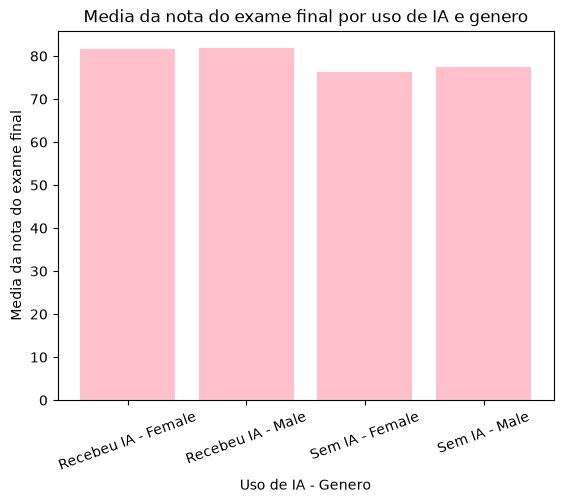

In [21]:
# grafico de barras: nota do exame final por genero, dentro de cada grupo de uso de IA
cores_recebeu_ia = df_med_cruzado.index.get_level_values("recebeu_ia") + " - " + df_med_cruzado.index.get_level_values("gender")

plt.bar(cores_recebeu_ia, df_med_cruzado["final_exam_score"], color="pink")
plt.title("Media da nota do exame final por uso de IA e genero")
plt.xlabel("Uso de IA - Genero")
plt.ylabel("Media da nota do exame final")
plt.xticks(rotation=20)
plt.show()

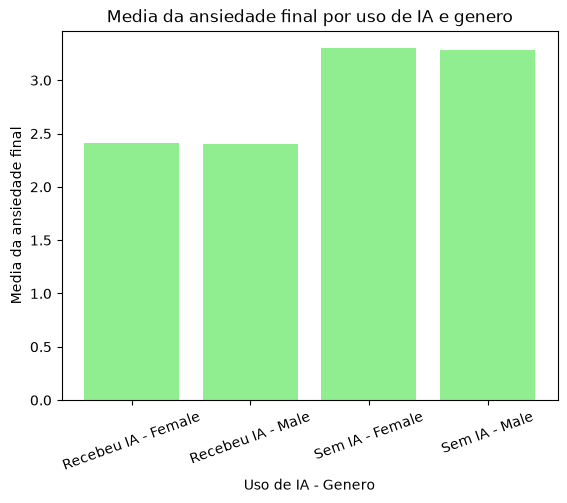

In [22]:
# grafico de barras: ansiedade final por genero, dentro de cada grupo de uso de IA
plt.bar(cores_recebeu_ia, df_med_cruzado["final_stem_anxiety"], color="lightgreen")
plt.title("Media da ansiedade final por uso de IA e genero")
plt.xlabel("Uso de IA - Genero")
plt.ylabel("Media da ansiedade final")
plt.xticks(rotation=20)
plt.show()